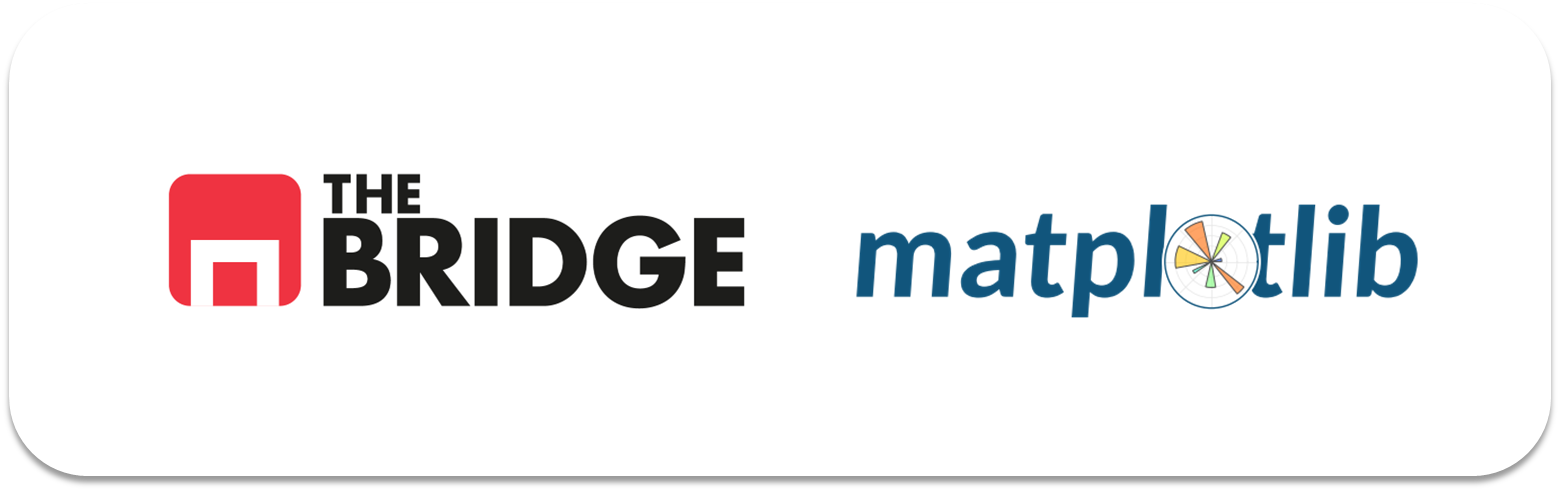

# Visualización con Matplotlib: Histogramas y diagramas de caja

Vamos a ver de forma sencilla como hacer los gráficos que nos generaban las funciones que empleamos en las visualizaciones analiticas del sprint anteior. En concreto, veremos los histogramas y los boxplots:

In [1]:
#%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = np.random.randn(1000)


### Histogramas

Tan sencillo como:

(array([  6.,  33., 108., 233., 281., 215.,  96.,  22.,   5.,   1.]),
 array([-3.12182683, -2.41964976, -1.71747269, -1.01529562, -0.31311855,
         0.38905853,  1.0912356 ,  1.79341267,  2.49558974,  3.19776681,
         3.89994388]),
 <BarContainer object of 10 artists>)

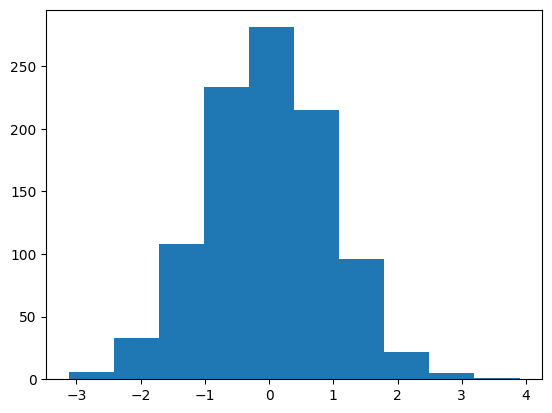

In [3]:
plt.hist(data)

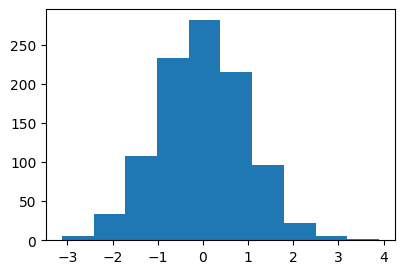

In [7]:
fig = plt.figure(figsize=(4.5,3)) #ancho 4.5, alto 3
ax = plt.axes()
ax.hist(data);


La función ``hist()`` tiene muchas opciones para ajustar tanto el cálculo como la visualización; aquí tienes un ejemplo de un histograma más personalizado (en el que tocamos el número de columnas `bins`, la transparencia y el color):


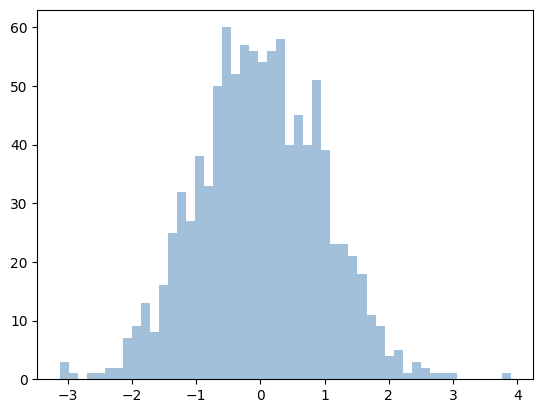

In [13]:
plt.hist(data,
         bins = 50,
         alpha = 0.5,
         color = "steelblue"
        );

# la transparencia alta (cerca de 0) es interesante para comprarar histogramas entre sí

La transparencia es particularmente interesante para comparar histogramas o mostrar dicha comparación (y aprovecho para enseñarte un truco para cuando tengas argumentos repetidos que poner en tus llamadas a función):

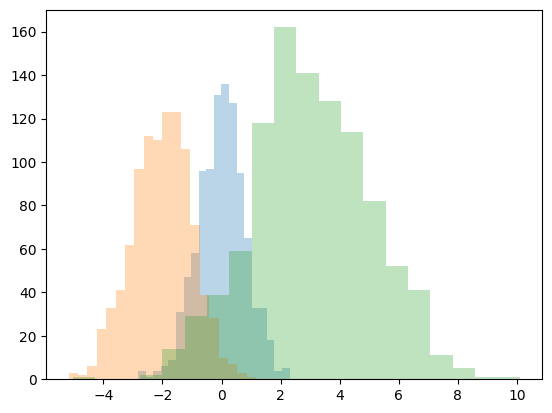

In [17]:
x1 = np.random.normal(0, 0.8, 1000)
x2 = np.random.normal(-2, 1, 1000)
x3 = np.random.normal(3, 2, 1000)

kwargs = dict(alpha = 0.3, bins = 20)

plt.hist(x1, **kwargs)
plt.hist(x2, **kwargs)
plt.hist(x3, **kwargs);

Es también el momento de enseñarte a capturar los límites de esos bines:

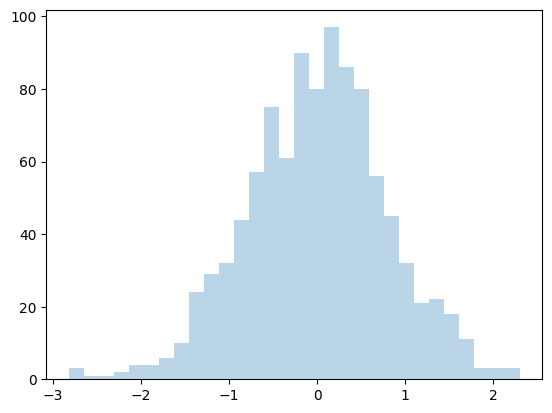

In [20]:
fig = plt.figure()
ax = plt.axes()
limites = ax.hist(x1, alpha = 0.3, bins = 30)

Limites es una tupla en la que el primer valor son los conteos y el segundo los límites de las barras:

In [29]:
limites[0]

# esto nos permite obtener la 'altura' de cada barra del histograma

array([ 3.,  1.,  1.,  2.,  4.,  4.,  6., 10., 24., 29., 32., 44., 57.,
       75., 61., 90., 80., 97., 86., 80., 56., 45., 32., 21., 22., 18.,
       11.,  3.,  3.,  3.])

In [30]:
limites[1]

# esto nos permite obtener los limites de 'anchura' de cada barra, como vemos están en orden

array([-2.82424521, -2.65343363, -2.48262205, -2.31181048, -2.1409989 ,
       -1.97018732, -1.79937574, -1.62856417, -1.45775259, -1.28694101,
       -1.11612944, -0.94531786, -0.77450628, -0.60369471, -0.43288313,
       -0.26207155, -0.09125997,  0.0795516 ,  0.25036318,  0.42117476,
        0.59198633,  0.76279791,  0.93360949,  1.10442106,  1.27523264,
        1.44604422,  1.6168558 ,  1.78766737,  1.95847895,  2.12929053,
        2.3001021 ])


### Boxplots

Los diagramas de caja eran esos diagramas en los que resumíamos las medidas de posición y añadíamos una posible formar de obtener valores anómalos, extremos o outliers. En forma de diagrama:


```text
     Q1-1.5IQR   Q1  mediana  Q3   Q3+1.5IQR
                  |-----:-----|
  o      |--------|     :     |--------|    o  o
                  |-----:-----|
flier             <----------->            fliers/outlier
                       IQR

```

Donde IQR es el rango intercuartilico (la diferencia entre el valor de Q3 o tercer cuartil o percentil-75 y el valor de Q1 o primer cuartil, o percentil-25)

En matplotlib:

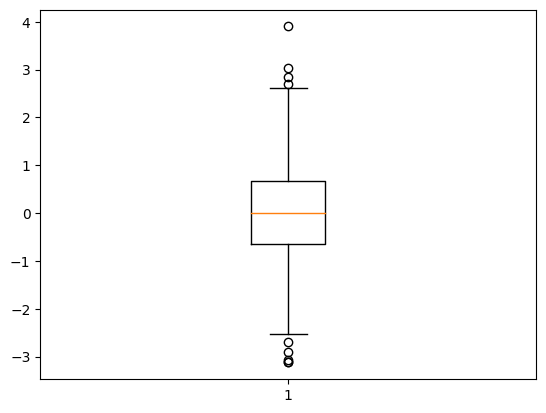

In [31]:
plt.boxplot(data, whis = 1.5);

En el caso de matplotlib empleamos por defecto diagramas de caja verticales. Pero podemos cambiarlo:

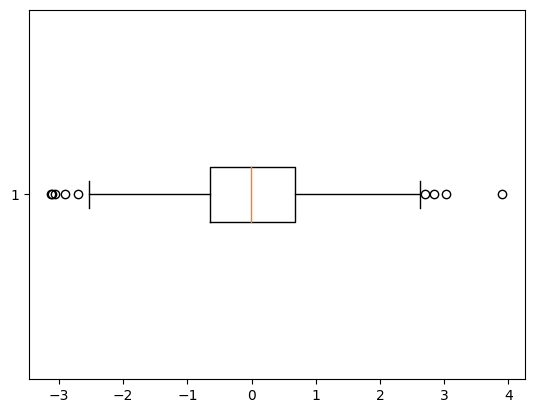

In [35]:
plt.boxplot(data, vert = False);

Y podemos mostrar varios juntos:

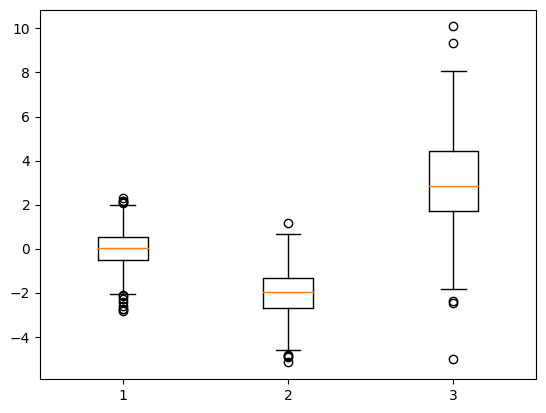

In [42]:
plt.boxplot([x1,x2,x3]);

# si no decimos nada al whis =, el valor predeterminado es 1.5 (longitud del bigote, lo que determina donde empiezan a ser outliers)